# THS 2017 Trips File — AM-Peak OD Matrices by Day and Mode

Builds OD matrices from `Input/trips_ths_2017.xlsx` (one row per activity):

- **Trips by activity order**: within each person (`PerID3`) and survey day (`SurveyDay` = 1/2), activities are ordered by `placeno`; a trip runs from the previous activity's `actTaz` to the current one's.
- **Departure hour** (`Dep_h`) belongs to the *origin* row — the hour of departing that activity toward the next one. AM peak = `Dep_h` ∈ {6, 7, 8} (6:00–9:00).
- **Mode** of a trip is the `mode` of the *destination* row (the mode used to arrive). The column already carries the aggregated groups CAR / TRANSIT / RAIL / OTHER; `IRR` marks first activities only, which never form trips.
- **Weights**: each trip contributes its `new_wf`.

Outputs: one matrix per day × mode plus an all-mode matrix per day, under `Output/ths2017/`.

In [1]:
import numpy as np
import pandas as pd
import os

df = pd.read_excel('Input/trips_ths_2017.xlsx')
print(f"{len(df):,} activity rows, {df['PerID3'].nunique():,} persons, days: {sorted(df['SurveyDay'].unique())}")
assert not df.duplicated(subset=['PerID3', 'SurveyDay', 'placeno']).any()
assert df.loc[df['mode'] == 'IRR', 'placeno'].eq(1).all(), "IRR must only mark first activities"


146,394 activity rows, 16,401 persons, days: [np.int64(1), np.int64(2)]


In [2]:
d = df.sort_values(['PerID3', 'SurveyDay', 'placeno']).copy()
g = d.groupby(['PerID3', 'SurveyDay'])
d['origin'] = g['actTaz'].shift(1)
d['trip_dep_h'] = g['Dep_h'].shift(1)      # departure hour of the trip = origin row's Dep_h
d['destination'] = d['actTaz']

trips = d.dropna(subset=['origin', 'destination', 'trip_dep_h'])
trips = trips[trips['trip_dep_h'].isin([6, 7, 8])]
assert (trips['mode'] != 'IRR').all()

summary = (trips.groupby(['SurveyDay', 'mode'])
                .agg(sampled_trips=('new_wf', 'size'), expanded_trips=('new_wf', 'sum')))
summary['share'] = summary['expanded_trips'] / summary.groupby('SurveyDay')['expanded_trips'].transform('sum')
print(f"AM-peak trips: day 1 = {len(trips[trips['SurveyDay']==1]):,} sampled "
      f"({trips.loc[trips['SurveyDay']==1,'new_wf'].sum():,.0f} expanded), "
      f"day 2 = {len(trips[trips['SurveyDay']==2]):,} ({trips.loc[trips['SurveyDay']==2,'new_wf'].sum():,.0f})")
summary.round({'expanded_trips': 0, 'share': 3})

AM-peak trips: day 1 = 14,078 sampled (2,196,813 expanded), day 2 = 13,982 (2,172,451)


sampled_trips  expanded_trips  share
SurveyDay mode                                         
1         CAR               8449       1380188.0  0.628
          OTHER             4556        656482.0  0.299
          RAIL                92         17219.0  0.008
          TRANSIT            981        142924.0  0.065
2         CAR               8292       1343321.0  0.618
          OTHER             4597        669334.0  0.308
          RAIL               106         19210.0  0.009
          TRANSIT            987        140585.0  0.065

In [3]:
MODES = ['CAR', 'TRANSIT', 'RAIL', 'OTHER']
os.makedirs('Output/ths2017', exist_ok=True)

for day in (1, 2):
    td = trips[trips['SurveyDay'] == day]
    m_all = pd.crosstab(td['origin'], td['destination'], values=td['new_wf'], aggfunc='sum').fillna(0)
    m_all.to_csv(f'Output/ths2017/matrix_day{day}_ALL.csv')
    total_check = 0
    for mode in MODES:
        tm = td[td['mode'] == mode]
        m = pd.crosstab(tm['origin'], tm['destination'], values=tm['new_wf'], aggfunc='sum').fillna(0)
        m.to_csv(f'Output/ths2017/matrix_day{day}_{mode}.csv')
        total_check += m.sum().sum()
        print(f"matrix_day{day}_{mode}.csv:  shape {str(m.shape):>10},  {m.sum().sum():>12,.0f} expanded trips")
    assert abs(total_check - m_all.sum().sum()) < 1e-6
    print(f"matrix_day{day}_ALL.csv:      shape {str(m_all.shape):>10},  {m_all.sum().sum():>12,.0f} expanded trips (modes sum exactly)\n")

matrix_day1_CAR.csv:  shape (626, 804),     1,380,188 expanded trips
matrix_day1_TRANSIT.csv:  shape (291, 312),       142,924 expanded trips
matrix_day1_RAIL.csv:  shape   (65, 70),        17,219 expanded trips


matrix_day1_OTHER.csv:  shape (442, 539),       656,482 expanded trips
matrix_day1_ALL.csv:      shape (651, 878),     2,196,813 expanded trips (modes sum exactly)



matrix_day2_CAR.csv:  shape (628, 781),     1,343,321 expanded trips
matrix_day2_TRANSIT.csv:  shape (284, 321),       140,585 expanded trips
matrix_day2_RAIL.csv:  shape   (81, 75),        19,210 expanded trips


matrix_day2_OTHER.csv:  shape (450, 533),       669,334 expanded trips
matrix_day2_ALL.csv:      shape (660, 859),     2,172,451 expanded trips (modes sum exactly)



## Day-averaged matrices

The two survey days are different by activity (different trip patterns for the same people), so the representative weekday matrix is the **average of the two days**: every cell is `(day1 + day2) / 2` over the union of observed zones. Produced for the all-mode matrix and each mode group.

In [4]:
def day_matrix(day, mode=None):
    td = trips[trips['SurveyDay'] == day]
    if mode is not None:
        td = td[td['mode'] == mode]
    return pd.crosstab(td['origin'], td['destination'], values=td['new_wf'], aggfunc='sum').fillna(0)

def averaged(mode=None):
    m1, m2 = day_matrix(1, mode), day_matrix(2, mode)
    idx = sorted(set(m1.index) | set(m2.index))
    cols = sorted(set(m1.columns) | set(m2.columns))
    m1 = m1.reindex(index=idx, columns=cols, fill_value=0)
    m2 = m2.reindex(index=idx, columns=cols, fill_value=0)
    return (m1 + m2) / 2

avg_all = averaged()
avg_all.to_csv('Output/ths2017/matrix_avg_ALL.csv')
total_check = 0
for mode in MODES:
    m = averaged(mode)
    m.to_csv(f'Output/ths2017/matrix_avg_{mode}.csv')
    total_check += m.sum().sum()
    print(f"matrix_avg_{mode}.csv:  shape {str(m.shape):>10},  {m.sum().sum():>12,.1f} avg-weekday trips")
assert abs(total_check - avg_all.sum().sum()) < 1e-6
print(f"matrix_avg_ALL.csv:      shape {str(avg_all.shape):>10},  {avg_all.sum().sum():>12,.1f} avg-weekday trips (modes sum exactly)")

matrix_avg_CAR.csv:  shape (697, 906),   1,361,754.4 avg-weekday trips
matrix_avg_TRANSIT.csv:  shape (333, 385),     141,754.7 avg-weekday trips
matrix_avg_RAIL.csv:  shape (104, 107),      18,214.4 avg-weekday trips


matrix_avg_OTHER.csv:  shape (488, 580),     662,908.1 avg-weekday trips
matrix_avg_ALL.csv:      shape (735, 988),   2,184,631.8 avg-weekday trips (modes sum exactly)


## Conversion to the study zone systems (via `Input/TAZ_2636_Keys.xlsx`)

Chain: `actTaz` (2636 system) → `TAZ_1250` (identical ids to the study keys' `TAZ_1270`) → study `TAZ_NUMBER` (778 zones). The keys cover every `actTaz` (100% of trip ends); 95.9% of weighted trips have both ends inside the northern study area.

The last link is one-to-many (a 1250-zone contains up to 8 study TAZs), so each trip's weight is **allocated proportionally** to child TAZ pairs using cellular structure: origin side by the children's cellular outflow shares, destination side by inflow shares (uniform fallback where cellular has no volume). Formally `M_taz = Sₒᵀ · M₁₂₅₀ · S_d`. Superzone (`SZ_NEW`) and GS aggregations then follow exactly from the TAZ matrices.

In [5]:
# mapping chain and allocation matrices
k26 = pd.read_excel('Input/TAZ_2636_Keys.xlsx').drop_duplicates('TAZ_2636')
map_2636_1250 = k26.set_index('TAZ_2636')['TAZ_1250']

keys_raw = pd.read_csv('Input/Matrices/1270_02_09_2021_TAZ_North_keys.csv', encoding='windows-1255')
kn = keys_raw[['TAZ_1270', 'TAZ_NUMBER']].dropna(subset=['TAZ_NUMBER'])
kn['TAZ_NUMBER'] = kn['TAZ_NUMBER'].astype(int)

# cellular matrix at study-TAZ level (validated reconstruction) for allocation shares
cellular = pd.read_csv('Input/Matrices/AvgDayHourlyTrips201819_1270_weekday_v1.csv')[['fromZone', 'ToZone', 'h6', 'h7', 'h8']]
kd = kn.drop_duplicates('TAZ_NUMBER')
c = cellular.merge(kd.rename(columns={'TAZ_1270': 'fromZone', 'TAZ_NUMBER': 'fromTaz'}), on='fromZone')
c = c.merge(kd.rename(columns={'TAZ_1270': 'ToZone', 'TAZ_NUMBER': 'ToTaz'}), on='ToZone')
cell_taz = c.groupby(['fromTaz', 'ToTaz'])[['h6', 'h7', 'h8']].sum().sum(axis=1).unstack().fillna(0)
TAZ = cell_taz.index
out_vol = cell_taz.sum(axis=1)
in_vol = cell_taz.sum(axis=0)

north_1250 = sorted(kd[kd['TAZ_NUMBER'].isin(TAZ)]['TAZ_1270'].unique())
z_idx = {z: i for i, z in enumerate(north_1250)}
children = kd[kd['TAZ_NUMBER'].isin(TAZ)].groupby('TAZ_1270')['TAZ_NUMBER'].apply(list)

def alloc_matrix(vol):
    S = np.zeros((len(north_1250), len(TAZ)))
    taz_pos = {t: j for j, t in enumerate(TAZ)}
    for z, kids in children.items():
        v = np.array([vol[t] for t in kids], float)
        shares = v / v.sum() if v.sum() > 0 else np.full(len(kids), 1 / len(kids))
        for t, s in zip(kids, shares):
            S[z_idx[z], taz_pos[t]] = s
    return S

S_o, S_d = alloc_matrix(out_vol), alloc_matrix(in_vol)
assert np.allclose(S_o.sum(axis=1), 1) and np.allclose(S_d.sum(axis=1), 1)
print(f"allocation matrices built: {len(north_1250)} northern 1250-zones -> {len(TAZ)} study TAZs")

allocation matrices built: 396 northern 1250-zones -> 778 study TAZs


In [6]:
# trips at 1250 level (averaged over the two days), then allocated to study TAZs
trips_m = trips.assign(o1250=trips['origin'].map(map_2636_1250), d1250=trips['actTaz'].map(map_2636_1250))
in_study = trips_m['o1250'].isin(z_idx) & trips_m['d1250'].isin(z_idx)
excl = trips_m.loc[~in_study, 'new_wf'].sum() / 2
print(f"trips excluded (an end outside the study area): {(~in_study).sum():,} sampled, {excl:,.0f} avg-weekday weighted")
tm = trips_m[in_study]

def m1250(day, mode=None):
    td = tm[tm['SurveyDay'] == day]
    if mode is not None:
        td = td[td['mode'] == mode]
    m = td.groupby(['o1250', 'd1250'])['new_wf'].sum().unstack().fillna(0)
    return m.reindex(index=north_1250, columns=north_1250, fill_value=0)

import os
os.makedirs('Output/ths2017/study_taz', exist_ok=True)
taz_mats = {}
for mode in MODES + [None]:
    label = mode if mode else 'ALL'
    avg1250 = (m1250(1, mode) + m1250(2, mode)) / 2
    m_taz = pd.DataFrame(S_o.T @ avg1250.values @ S_d, index=TAZ, columns=TAZ)
    assert abs(m_taz.values.sum() - avg1250.values.sum()) < 1e-6
    taz_mats[label] = m_taz
    m_taz.to_csv(f'Output/ths2017/study_taz/matrix_avg_{label}_taz.csv', float_format='%.6g')
    print(f"matrix_avg_{label}_taz.csv (778x778): {m_taz.values.sum():>12,.1f} avg-weekday trips")
assert abs(sum(taz_mats[m].values.sum() for m in MODES) - taz_mats['ALL'].values.sum()) < 1e-3

trips excluded (an end outside the study area): 1,197 sampled, 116,473 avg-weekday weighted


matrix_avg_CAR_taz.csv (778x778):  1,283,589.4 avg-weekday trips


matrix_avg_TRANSIT_taz.csv (778x778):    134,348.6 avg-weekday trips


matrix_avg_RAIL_taz.csv (778x778):      5,109.1 avg-weekday trips


matrix_avg_OTHER_taz.csv (778x778):    645,111.4 avg-weekday trips


matrix_avg_ALL_taz.csv (778x778):  2,068,158.5 avg-weekday trips


In [7]:
# exact SZ_NEW and GS aggregations of the allocated ALL matrix
taz_to_sz = keys_raw[['TAZ_NUMBER', 'SZ_NEW']].dropna().astype(int).drop_duplicates('TAZ_NUMBER').set_index('TAZ_NUMBER')['SZ_NEW']
taz_to_gs = pd.read_csv('Input/TAZ_GSnew.csv').set_index('TAZ')['GS']

def agg(m, mapping, name):
    m = m.copy()
    m.index.name, m.columns.name = 'o', 'd'
    long = m.stack().reset_index()
    long.columns = ['o', 'd', 'v']
    long['O'] = long['o'].map(mapping)
    long['D'] = long['d'].map(mapping)
    a = long.dropna(subset=['O', 'D']).groupby(['O', 'D'])['v'].sum().unstack().fillna(0)
    print(f"{name}: {a.shape}, {a.values.sum():,.0f} avg-weekday trips")
    return a

agg(taz_mats['ALL'], taz_to_sz, 'matrix_avg_ALL_sznew').to_csv('Output/ths2017/study_taz/matrix_avg_ALL_sznew.csv')
agg(taz_mats['ALL'], taz_to_gs, 'matrix_avg_ALL_gs').to_csv('Output/ths2017/study_taz/matrix_avg_ALL_gs.csv')

# validation: distribution similarity with the activities-based pipeline at superzone level
sz_this = agg(taz_mats['ALL'], taz_to_sz, 'validation copy')
act = pd.read_csv('Output/prob_sz_10_weighted.csv', index_col=0)
act.columns = act.columns.astype(float)
common = [z for z in sz_this.index if float(z) in act.index]
p1 = sz_this.loc[common, common].div(sz_this.loc[common, common].sum(axis=1), axis=0).fillna(0)
p2 = act.loc[[float(z) for z in common], [float(z) for z in common]]
r = np.corrcoef(p1.values.flatten(), p2.values.flatten())[0, 1]
print(f"\ncorrelation with the activities-based day-10 superzone probabilities: r = {r:.4f}")

matrix_avg_ALL_sznew: (36, 36), 2,068,158 avg-weekday trips
matrix_avg_ALL_gs: (25, 25), 2,068,158 avg-weekday trips


validation copy: (36, 36), 2,068,158 avg-weekday trips

correlation with the activities-based day-10 superzone probabilities: r = 0.9941


## Day 1 / Day 2 at GS level — scatter plots vs cellular

Each survey day separately: 1250-level matrix → allocated to study TAZs → aggregated to GS → row-normalized, plotted against the cellular GS probabilities.

GS-level correlations: day 1 vs cellular r = 0.8459, day 2 vs cellular r = 0.8438, day 1 vs day 2 r = 0.9846


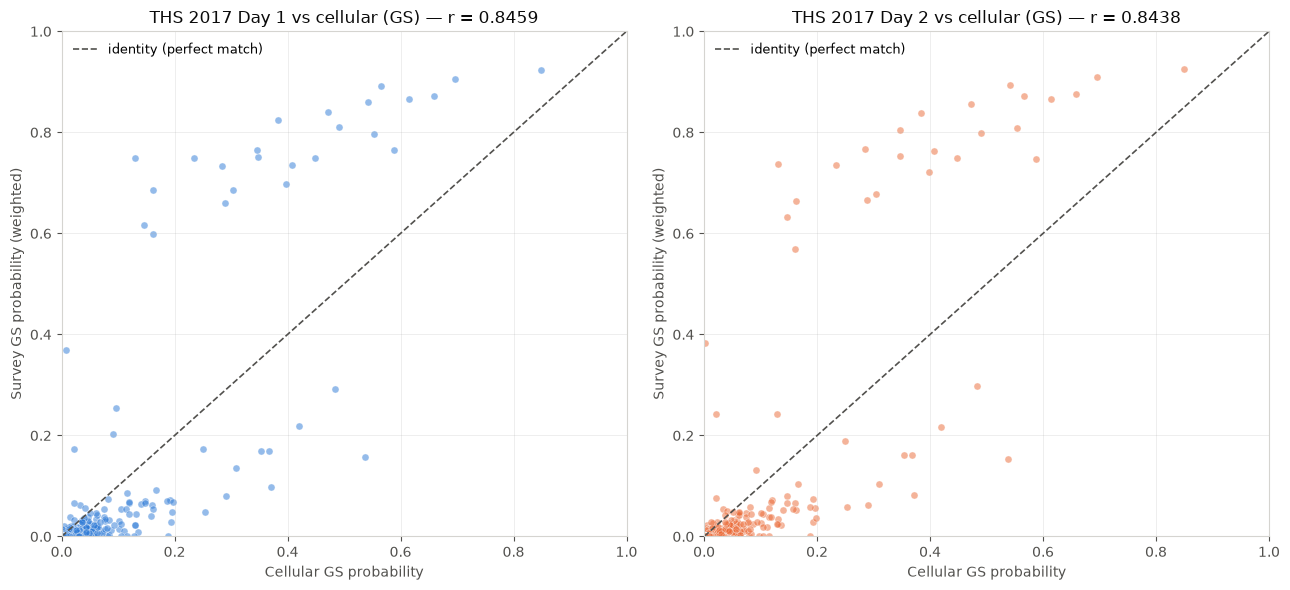

In [8]:
import matplotlib.pyplot as plt
BLUE, ORANGE, INK, INK2 = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e'

gs_of_taz = pd.Series({t: taz_to_gs.get(t) for t in TAZ})
GS = sorted(gs_of_taz.dropna().unique())
Mgs = np.zeros((len(TAZ), len(GS)))
gs_pos = {g: i for i, g in enumerate(GS)}
for j, t in enumerate(TAZ):
    Mgs[j, gs_pos[gs_of_taz[t]]] = 1

def gs_prob_from_day(day):
    m_taz = S_o.T @ m1250(day).values @ S_d
    m_gs = Mgs.T @ m_taz @ Mgs
    rs = m_gs.sum(axis=1, keepdims=True)
    return np.where(rs > 0, m_gs / rs, 0)

cell_gs = Mgs.T @ cell_taz.values @ Mgs
P_cell_gs = cell_gs / cell_gs.sum(axis=1, keepdims=True)

P1, P2 = gs_prob_from_day(1), gs_prob_from_day(2)
r1 = np.corrcoef(P1.flatten(), P_cell_gs.flatten())[0, 1]
r2 = np.corrcoef(P2.flatten(), P_cell_gs.flatten())[0, 1]
r12 = np.corrcoef(P1.flatten(), P2.flatten())[0, 1]
print(f"GS-level correlations: day 1 vs cellular r = {r1:.4f}, day 2 vs cellular r = {r2:.4f}, day 1 vs day 2 r = {r12:.4f}")

def panel(ax, y, color, title):
    ax.scatter(P_cell_gs.flatten(), y.flatten(), s=26, alpha=0.5, color=color, edgecolors='white', linewidths=0.5)
    ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, color=INK2, label='identity (perfect match)')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(title, color=INK, fontsize=12)
    ax.set_xlabel('Cellular GS probability', color=INK2)
    ax.set_ylabel('Survey GS probability (weighted)', color=INK2)
    ax.grid(True, alpha=0.25, linewidth=0.6)
    for s in ax.spines.values(): s.set_color('#d5d4d0')
    ax.tick_params(colors=INK2)
    ax.legend(frameon=False, loc='upper left', fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor='white')
panel(axes[0], P1, BLUE, f'THS 2017 Day 1 vs cellular (GS) — r = {r1:.4f}')
panel(axes[1], P2, ORANGE, f'THS 2017 Day 2 vs cellular (GS) — r = {r2:.4f}')
plt.tight_layout()
plt.savefig('Output/figures/ths2017_gs_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Notes

- The trip departure hour comes from the origin activity's `Dep_h` (when the traveler left it), matching the file's semantics; the destination row's `Dep_h` describes the departure *from* the destination later on.
- **`actTaz` uses its own zone system** (1,512 zones, range 3–2636) — it is *not* the 778-TAZ study system and matches none of the key table's systems (`TAZ_1270`, `TAZ_250`, `TAZ_33`, `TAZ_15`; the ~310 shared numbers are coincidental collisions). These matrices are valid within the trips file's zonation; connecting them to the study TAZ / superzone / GS systems requires an `actTaz` → study-TAZ correspondence table. No `actTaz` is 0, and the 5 null-TAZ rows drop out of trip formation.
- The mode column is already aggregated to the CAR / TRANSIT / RAIL / OTHER grouping used in `THS_2018_MTX_weighted_by_mode.ipynb`; `IRR` (first activity of a day, no arrival travel) never appears as a trip mode by construction — verified by assertion.